# Battery Report

Analysis of one or more CarbonShift solver battery runs.

Configure `RESULT_CSVS` in the next cell to point at the `battery_results_*.csv`
files you want to analyse.  All files are merged into a single DataFrame; a
`battery_id` column is added automatically from the file name.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 96
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Configure these paths (absolute or relative to the notebook location) ──────
RESULT_CSVS: list[str | Path] = [
    # "results/archive/full_0_par20_roll4_withStrategies/battery_results_default.csv",
    "results/battery_results_default.csv",
]

# ── Mode filter: which infeasibility modes to include in plots ───────────────
#   "greedy_fallback" | "relaxed_retry" | "both"
SHOW_MODES: str = "both"

# ── Visual styles for alternative strategies ─────────────────────────────────
STRATEGY_STYLE: dict = {
    "greedy_cheapest": {"color": "tab:green",  "marker": "D"},
    "bandit":          {"color": "tab:purple", "marker": "^"},
    "ant_colony":      {"color": "tab:cyan",   "marker": "*"},
}
_STRATEGY_FALLBACK_COLORS = ["tab:brown", "tab:pink", "tab:olive"]

# ── Metrics to plot ───────────────────────────────────────────────────────────
METRICS: list[dict] = [
    {"col": "solver_time_ms_avg",              "label": "Solver time (ms avg)"},
    {"col": "total_carbon_cost",               "label": "Total carbon cost"},
    {"col": "final_global_error",              "label": "Final global error"},
    {"col": "avg_global_error_per_slot",       "label": "Avg global error / slot"},
    {"col": "carbon_cost_saving_vs_baseline_pct", "label": "Carbon saving vs baseline (%)"},
    {"col": "total_rollbacks",                 "label": "Total rollbacks (Rust only)"},
    {"col": "max_consecutive_rollbacks",       "label": "Max consecutive rollbacks"},
    {"col": "peak_concurrent_workers",         "label": "Peak concurrent workers"},
    {"col": "avg_concurrent_workers",          "label": "Avg concurrent workers"},
]

MODE_STYLE: dict = {
    "greedy_fallback": {"linestyle": "-",  "marker": "o"},
    "relaxed_retry":   {"linestyle": "--", "marker": "s"},
}

BACKEND_COLOR: dict = {
    "python": {"greedy_fallback": "tab:blue",   "relaxed_retry": "tab:cyan"},
    "rust":   {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"},
}


In [2]:
_nb_dir = Path(__file__) if "__file__" in dir() else Path.cwd()

frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Results CSV not found: {p}")
    _df = pd.read_csv(p)
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    _df.insert(0, "battery_id", bid)
    frames.append(_df)

df = pd.concat(frames, ignore_index=True)
df["batch_size"] = df["batch_size"].astype(int)

for _rb_col in ("total_rollbacks", "max_consecutive_rollbacks",
                "peak_concurrent_workers", "avg_concurrent_workers"):
    if _rb_col not in df.columns:
        df[_rb_col] = 0
df["total_rollbacks"] = df["total_rollbacks"].fillna(0).astype(int)
df["max_consecutive_rollbacks"] = df["max_consecutive_rollbacks"].fillna(0).astype(int)

# ── Identify strategies vs. infeasibility modes ───────────────────────────────
_KNOWN_MODES = {"greedy_fallback", "relaxed_retry"}
STRATEGY_NAMES: list[str] = sorted(set(df["infeasibility_mode"].unique()) - _KNOWN_MODES)

df_modes = df[df["infeasibility_mode"].isin(_KNOWN_MODES)].copy()
df_strat = df[~df["infeasibility_mode"].isin(_KNOWN_MODES)].copy()

# Apply SHOW_MODES filter
if SHOW_MODES == "greedy_fallback":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "greedy_fallback"].copy()
elif SHOW_MODES == "relaxed_retry":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "relaxed_retry"].copy()

scenarios   = sorted(df["scenario_id"].unique())
batch_sizes = sorted(df_modes["batch_size"].unique())
combos = sorted(
    df_modes[["backend", "infeasibility_mode"]].drop_duplicates().itertuples(index=False, name=None)
)

def _xaxis_info():
    """Build categorical x-axis covering batch sizes then strategies."""
    labels     = [f"N={n}" for n in batch_sizes] + STRATEGY_NAMES
    bs_to_x    = {n: i for i, n in enumerate(batch_sizes)}
    strat_to_x = {s: len(batch_sizes) + i for i, s in enumerate(STRATEGY_NAMES)}
    return labels, bs_to_x, strat_to_x, len(batch_sizes)

x_labels, bs_to_x, strat_to_x, n_bs = _xaxis_info()

print(f"Loaded {len(df)} rows from {len(frames)} CSV file(s).")
print(f"Batteries   : {sorted(df['battery_id'].unique())}")
print(f"Scenarios   : {scenarios}")
print(f"Backends    : {sorted(df['backend'].unique())}")
print(f"Modes shown : {sorted(df_modes['infeasibility_mode'].unique())} (SHOW_MODES={SHOW_MODES!r})")
print(f"Strategies  : {STRATEGY_NAMES}")
print(f"Batch sizes : {batch_sizes}")

df


Loaded 11 rows from 1 CSV file(s).
Batteries   : ['default']
Scenarios   : ['xxhigh_load_150']
Backends    : ['rust']
Modes shown : ['relaxed_retry'] (SHOW_MODES='both')
Strategies  : ['ant_colony', 'bandit', 'greedy_cheapest']
Batch sizes : [np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(16), np.int64(20)]


,battery_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,total_carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline_pct,peak_concurrent_workers,avg_concurrent_workers
0,default,xxhigh_load_150,rust,1,relaxed_retry,1.0147,12998.7558,3.9995,3.9977,0,104,0,0,55644.1350,76.6395,20,4.7239
1,default,xxhigh_load_150,rust,4,relaxed_retry,4.0355,12768.9841,3.9971,3.9998,0,315,0,0,55644.1350,77.0524,20,9.0019
2,default,xxhigh_load_150,rust,6,relaxed_retry,18.2829,14190.8104,3.9711,3.9627,0,2714,0,0,55644.1350,74.4972,20,12.4569
3,default,xxhigh_load_150,rust,8,relaxed_retry,38.0210,14895.7254,3.9451,3.9360,0,3026,0,0,55644.1350,73.2304,20,12.4171
4,default,xxhigh_load_150,rust,10,relaxed_retry,69.0181,15509.0227,3.8984,3.8903,0,3189,0,0,55644.1350,72.1282,20,11.4190
5,default,xxhigh_load_150,rust,12,relaxed_retry,128.3207,15841.6703,3.8867,3.8702,0,3253,0,0,55644.1350,71.5304,20,10.3552
6,default,xxhigh_load_150,rust,16,relaxed_retry,1017.8241,15565.6163,3.8720,3.8459,0,2615,0,0,55644.1350,72.0265,20,8.4378
7,default,xxhigh_load_150,rust,20,relaxed_retry,4025.7289,16530.1380,3.8496,3.8447,0,769,0,0,55644.1350,70.2931,20,7.1017
8,default,xxhigh_load_150,rust,0,greedy_cheapest,0.0000,19120.9027,3.9390,3.9237,0,0,0,0,55644.1350,65.6372,0,0.0000
9,default,xxhigh_load_150,rust,0,bandit,0.0000,15063.1742,4.0000,3.9632,0,0,0,0,55644.1350,72.9294,0,0.0000


## Execution timings

Wall-clock time per scenario and total battery run time, read from
`battery_timings_*.csv` files that mirror the `RESULT_CSVS` list above.


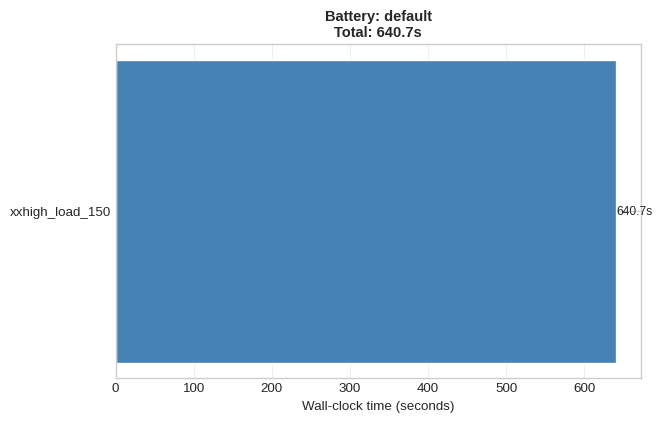


Per-battery totals:
  default: 640.7s


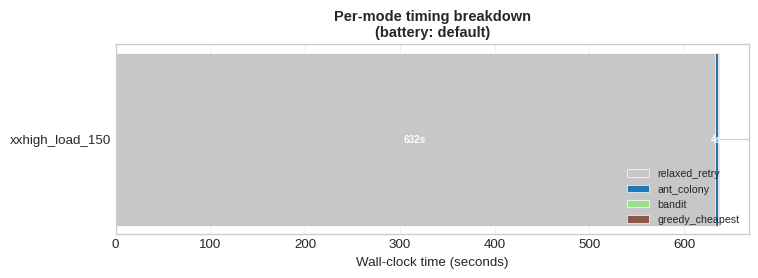

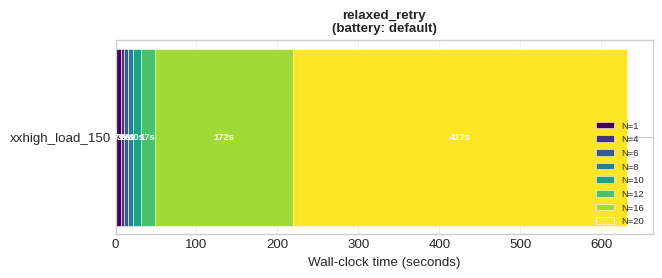


### Strategy execution times (ms)


/tmp/ipykernel_58748/2206901864.py:167: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_val = float(row["mean"])
/tmp/ipykernel_58748/2206901864.py:168: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val  = float(row["min"])
/tmp/ipykernel_58748/2206901864.py:169: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_val  = float(row["max"])


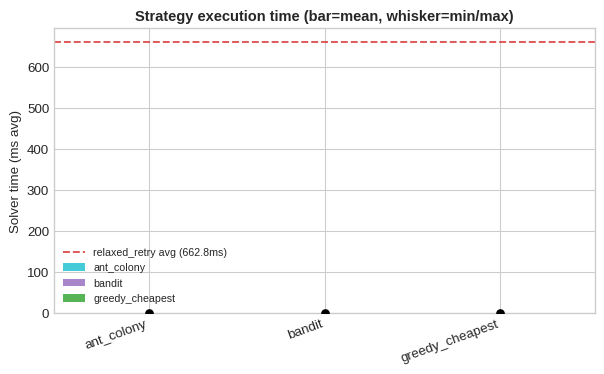

,strategy,min,mean,max
0,ant_colony,0.0000,0.0000,0.0000
1,bandit,0.0000,0.0000,0.0000
2,greedy_cheapest,0.0000,0.0000,0.0000


In [3]:
timing_frames = []
per_n_frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    timing_path = p.parent / f"battery_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    per_n_path  = p.parent / f"per_n_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    if not timing_path.exists():
        print(f"WARNING: timing file not found: {timing_path}")
        continue
    _t = pd.read_csv(timing_path)
    _t.insert(0, "battery_id", bid)
    timing_frames.append(_t)
    if per_n_path.exists():
        _pn = pd.read_csv(per_n_path)
        _pn.insert(0, "battery_id", bid)
        per_n_frames.append(_pn)

if not timing_frames:
    print("No timing files found – run the battery first to generate timings.")
else:
    tdf = pd.concat(timing_frames, ignore_index=True)
    scenario_times = tdf[tdf["scenario_id"] != "__battery_total__"].copy()
    battery_totals = tdf[tdf["scenario_id"] == "__battery_total__"].copy()
    battery_ids = scenario_times["battery_id"].unique().tolist()
    n_batteries = len(battery_ids)

    # ── Chart 1: total wall-clock per scenario ────────────────────────────────
    fig, axes = plt.subplots(1, n_batteries, figsize=(max(7, 5 * n_batteries), 4.5), squeeze=False)
    for ax, bid in zip(axes[0], battery_ids):
        sub = scenario_times[scenario_times["battery_id"] == bid].sort_values("scenario_id")
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        total_s = float(total_row["elapsed_seconds"].iloc[0]) if not total_row.empty else sub["elapsed_seconds"].sum()
        bars = ax.barh(sub["scenario_id"], sub["elapsed_seconds"], color="steelblue", edgecolor="white")
        for bar, val in zip(bars, sub["elapsed_seconds"]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}s", va="center", fontsize=9)
        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(f"Battery: {bid}\nTotal: {total_s:.1f}s", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("\nPer-battery totals:")
    for bid in battery_ids:
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        if not total_row.empty:
            print(f"  {bid}: {float(total_row['elapsed_seconds'].iloc[0]):.1f}s")

# ── Chart 2: per-N/strategy stacked breakdown ─────────────────────────────────
if per_n_frames:
    pndf = pd.concat(per_n_frames, ignore_index=True)
    battery_ids_pn = pndf["battery_id"].unique().tolist()

    # Build a color map: N values get a sequential palette, strategies get distinct colors
    all_modes = sorted(pndf["mode"].unique().tolist())
    all_ns    = sorted(pndf["batch_size"].unique().tolist())

    # Assign colors: use tab20 for many items
    cmap_n = plt.get_cmap("tab20")
    mode_color = {}
    for i, m in enumerate(all_modes):
        mode_color[m] = cmap_n(i / max(len(all_modes), 1))

    fig, axes = plt.subplots(1, len(battery_ids_pn),
                              figsize=(max(8, 6 * len(battery_ids_pn)), max(3, len(pndf["scenario_id"].unique()) * 0.7 + 2)),
                              squeeze=False)
    for ax, bid in zip(axes[0], battery_ids_pn):
        sub = pndf[pndf["battery_id"] == bid].copy()
        scenarios = sorted(sub["scenario_id"].unique().tolist())
        lefts = {s: 0.0 for s in scenarios}

        # Sort modes so N values come first (numerically), then strategies
        dp_modes  = sorted([m for m in sub["mode"].unique() if m in ("greedy_fallback", "relaxed_retry")])
        strat_modes = sorted([m for m in sub["mode"].unique() if m not in dp_modes])
        ordered_modes = dp_modes + strat_modes

        for mode in ordered_modes:
            vals = []
            for s in scenarios:
                row = sub[(sub["scenario_id"] == s) & (sub["mode"] == mode)]
                if row.empty:
                    vals.append(0.0)
                else:
                    # Sum all batch sizes for this mode (stacked within mode)
                    vals.append(float(row["elapsed_seconds"].sum()))

            color = mode_color.get(mode, "gray")
            bars = ax.barh(scenarios, vals,
                           left=[lefts[s] for s in scenarios],
                           color=color, label=mode, edgecolor="white", linewidth=0.5)
            for s, val in zip(scenarios, vals):
                if val > 1.0:
                    x = lefts[s] + val / 2
                    ax.text(x, scenarios.index(s), f"{val:.0f}s",
                            ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
            for s, val in zip(scenarios, vals):
                lefts[s] += val

        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(f"Per-mode timing breakdown\n(battery: {bid})", fontsize=11, fontweight="bold")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Chart 3: per-N breakdown per mode (N values stacked) ─────────────────
    for bid in battery_ids_pn:
        sub = pndf[pndf["battery_id"] == bid].copy()
        dp_sub = sub[sub["mode"].isin(["greedy_fallback", "relaxed_retry"])]
        if dp_sub.empty:
            continue
        modes_present = sorted(dp_sub["mode"].unique().tolist())
        scenarios = sorted(dp_sub["scenario_id"].unique().tolist())

        fig, axes2 = plt.subplots(1, len(modes_present),
                                   figsize=(max(7, 5 * len(modes_present)), max(3, len(scenarios) * 0.8 + 2)),
                                   squeeze=False)
        for ax, mode in zip(axes2[0], modes_present):
            msub = dp_sub[dp_sub["mode"] == mode].copy()
            ns_present = sorted(msub["batch_size"].unique().tolist())
            n_colors = plt.get_cmap("viridis")(
                [i / max(len(ns_present) - 1, 1) for i in range(len(ns_present))]
            )
            lefts2 = {s: 0.0 for s in scenarios}
            for ni, (n, col) in enumerate(zip(ns_present, n_colors)):
                vals2 = []
                for s in scenarios:
                    row = msub[(msub["scenario_id"] == s) & (msub["batch_size"] == n)]
                    vals2.append(float(row["elapsed_seconds"].iloc[0]) if not row.empty else 0.0)
                ax.barh(scenarios, vals2, left=[lefts2[s] for s in scenarios],
                        color=col, label=f"N={n}", edgecolor="white", linewidth=0.4)
                for s, val in zip(scenarios, vals2):
                    if val > 2.0:
                        x = lefts2[s] + val / 2
                        ax.text(x, scenarios.index(s), f"{val:.0f}s",
                                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
                for s, val in zip(scenarios, vals2):
                    lefts2[s] += val
            ax.set_xlabel("Wall-clock time (seconds)")
            ax.set_title(f"{mode}\n(battery: {bid})", fontsize=10, fontweight="bold")
            ax.legend(loc="lower right", fontsize=7)
            ax.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No per-N timing files found – run the battery again to generate per_n_timings_*.csv.")

# ── Strategy execution timing ─────────────────────────────────────────────────
if not df_strat.empty and "solver_time_ms_avg" in df_strat.columns:
    print("\n### Strategy execution times (ms)")
    timing_strat = (
        df_strat
        .groupby("infeasibility_mode")["solver_time_ms_avg"]
        .agg(min="min", mean="mean", max="max")
        .reset_index()
        .rename(columns={"infeasibility_mode": "strategy"})
    )

    fig, ax = plt.subplots(figsize=(max(4, len(STRATEGY_NAMES) * 1.8 + 1), 4))
    for i, strat in enumerate(STRATEGY_NAMES):
        row = timing_strat[timing_strat["strategy"] == strat]
        if row.empty:
            continue
        mean_val = float(row["mean"])
        min_val  = float(row["min"])
        max_val  = float(row["max"])
        color = STRATEGY_STYLE.get(strat, {}).get("color", _STRATEGY_FALLBACK_COLORS[i % len(_STRATEGY_FALLBACK_COLORS)])
        ax.bar(i, mean_val, color=color, alpha=0.8, label=strat)
        ax.plot([i, i], [min_val, max_val], color="black", linewidth=2.5, zorder=5)
        ax.scatter([i], [mean_val], color="black", s=30, zorder=6)

    # Reference lines: avg solver time for each mode
    if not df_modes.empty:
        mode_colors = {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"}
        for mode, grp in df_modes.groupby("infeasibility_mode"):
            avg = grp["solver_time_ms_avg"].mean()
            ax.axhline(avg, linestyle="--", linewidth=1.4, alpha=0.8,
                       color=mode_colors.get(mode, "gray"),
                       label=f"{mode} avg ({avg:.1f}ms)")

    ax.set_xticks(range(len(STRATEGY_NAMES)))
    ax.set_xticklabels(STRATEGY_NAMES, rotation=20, ha="right")
    ax.set_ylabel("Solver time (ms avg)")
    ax.set_title("Strategy execution time (bar=mean, whisker=min/max)", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    display(timing_strat.round(3))
else:
    print("No strategy data loaded – run battery with additional_strategies to see timings.")


## Per-scenario metrics

One figure per scenario.  Each figure shows all metrics; lines are split by
`(backend, infeasibility_mode)` combination.


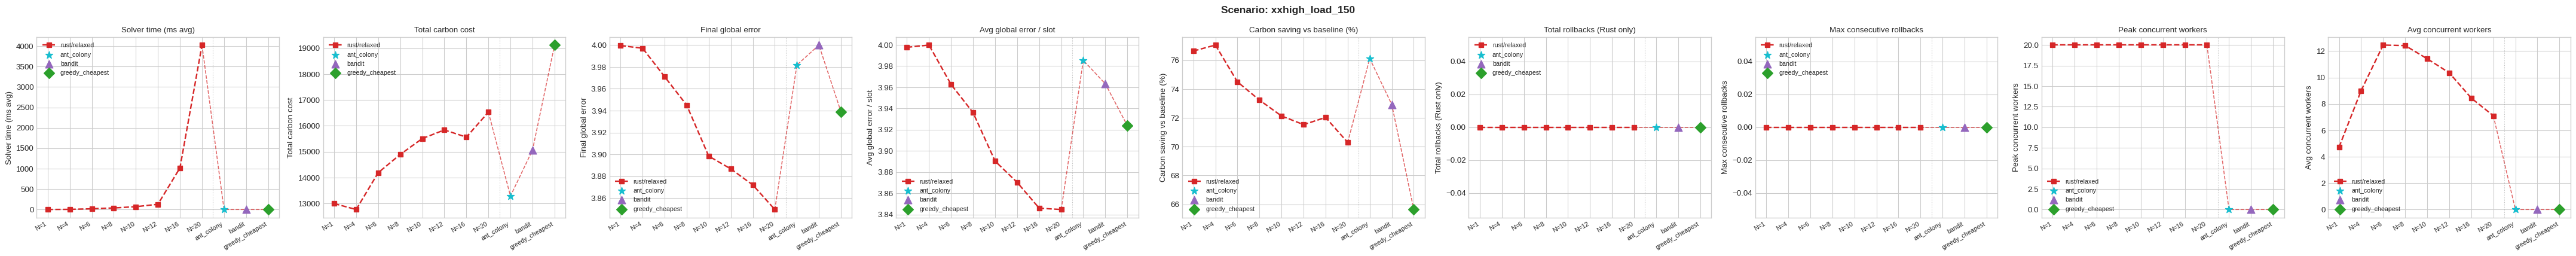

In [15]:
def _series_label(backend: str, mode: str) -> str:
    mode_short = "greedy" if mode == "greedy_fallback" else "relaxed"
    return f"{backend}/{mode_short}"

def _series_style(backend: str, mode: str) -> dict:
    color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
    style = MODE_STYLE.get(mode, {})
    return {"color": color, **style}

def _strategy_style(name: str) -> dict:
    if name in STRATEGY_STYLE:
        return STRATEGY_STYLE[name]
    i = STRATEGY_NAMES.index(name) % len(_STRATEGY_FALLBACK_COLORS)
    return {"color": _STRATEGY_FALLBACK_COLORS[i], "marker": "X"}

def _apply_xaxis(ax, rotate=30):
    if STRATEGY_NAMES and n_bs > 0:
        ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.8, alpha=0.5, color="gray")
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=rotate, ha="right", fontsize=8)

n_metrics = len(METRICS)

for sid in scenarios:
    s_df_m = df_modes[df_modes["scenario_id"] == sid].sort_values("batch_size")
    s_df_s = df_strat[df_strat["scenario_id"] == sid] if not df_strat.empty else pd.DataFrame()

    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5))
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f"Scenario: {sid}", fontsize=13, fontweight="bold")

    for ax, m in zip(axes, METRICS):
        for backend, mode in combos:
            sub = s_df_m[(s_df_m["backend"] == backend) & (s_df_m["infeasibility_mode"] == mode)]
            if sub.empty:
                continue
            xs = [bs_to_x[bs] for bs in sub["batch_size"]]
            ys = list(sub[m["col"]].values)
            sty = _series_style(backend, mode)
            ax.plot(xs, ys,
                    label=_series_label(backend, mode), linewidth=1.8, **sty)
            # Dashed extension from last N-point through strategy points
            if not s_df_s.empty and STRATEGY_NAMES:
                ext_xs = [xs[-1]]
                ext_ys = [ys[-1]]
                for strat in STRATEGY_NAMES:
                    sub_s = s_df_s[
                        (s_df_s["backend"] == backend) &
                        (s_df_s["infeasibility_mode"] == strat)
                    ]
                    if sub_s.empty or m["col"] not in sub_s.columns:
                        continue
                    ext_xs.append(strat_to_x[strat])
                    ext_ys.append(float(sub_s[m["col"]].values[0]))
                if len(ext_xs) > 1:
                    ax.plot(ext_xs, ext_ys, linestyle="--", linewidth=1.2,
                            alpha=0.7, color=sty["color"])

        for strat in STRATEGY_NAMES:
            if s_df_s.empty:
                continue
            sub_s = s_df_s[s_df_s["infeasibility_mode"] == strat]
            if sub_s.empty or m["col"] not in sub_s.columns:
                continue
            sty = _strategy_style(strat)
            ax.scatter([strat_to_x[strat]], [sub_s[m["col"]].values[0]],
                       label=strat, s=90, zorder=5,
                       color=sty["color"], marker=sty["marker"])

        _apply_xaxis(ax)
        ax.set_ylabel(m["label"])
        ax.set_title(m["label"], fontsize=10)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


## All scenarios on one chart

Each metric is shown in a single figure with one subplot per `(backend, infeasibility_mode)`
combination.  All scenarios appear as separate lines to allow direct comparison.


/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


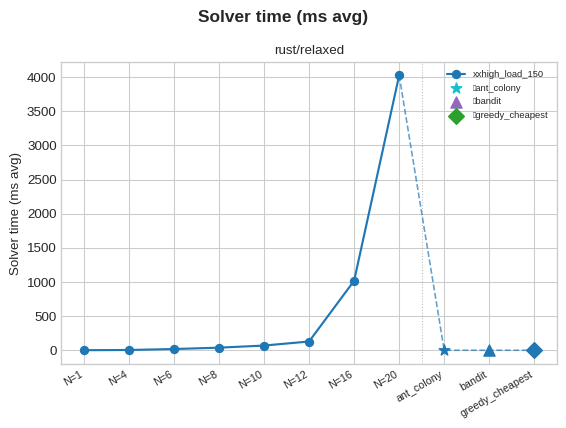

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


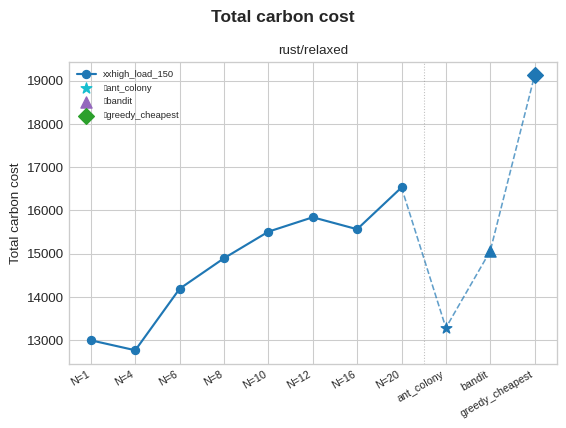

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


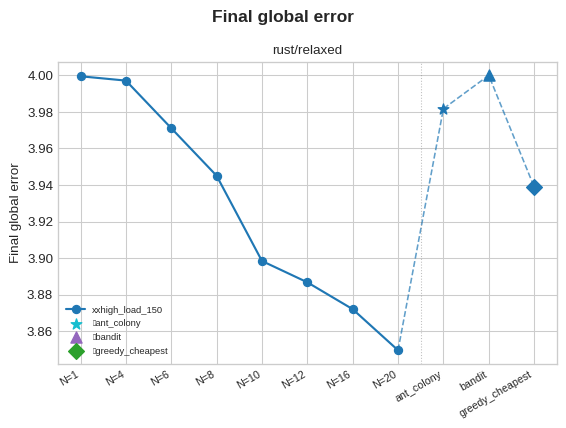

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


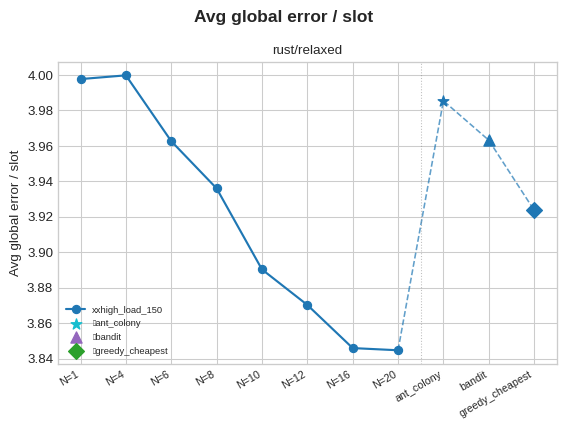

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


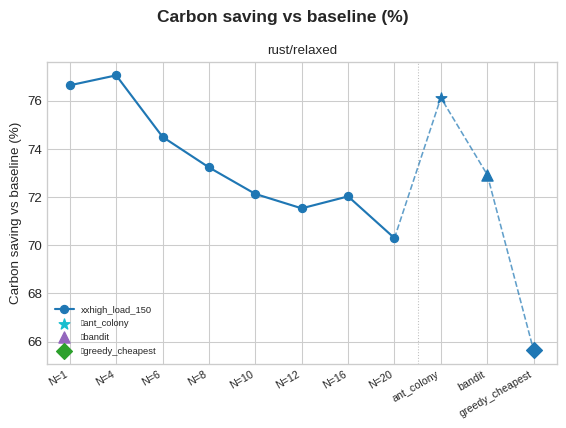

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


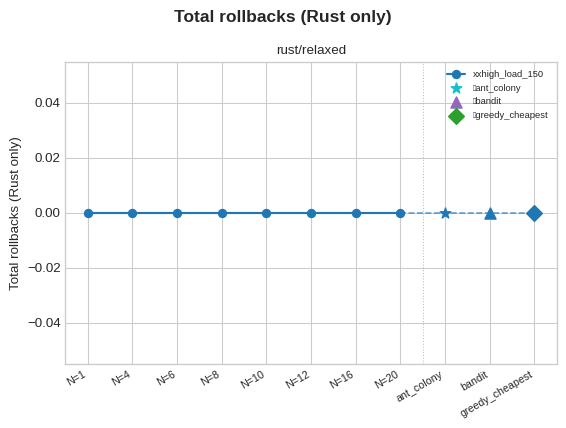

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


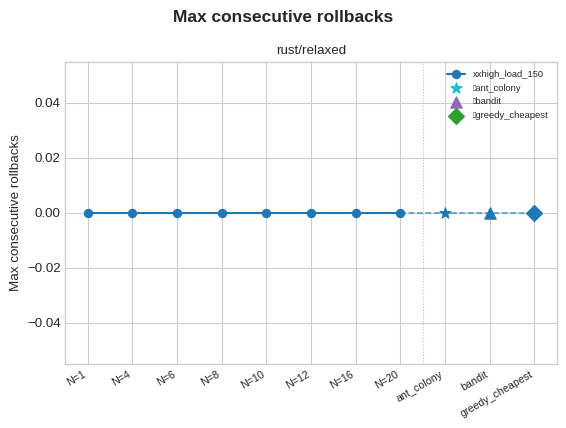

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


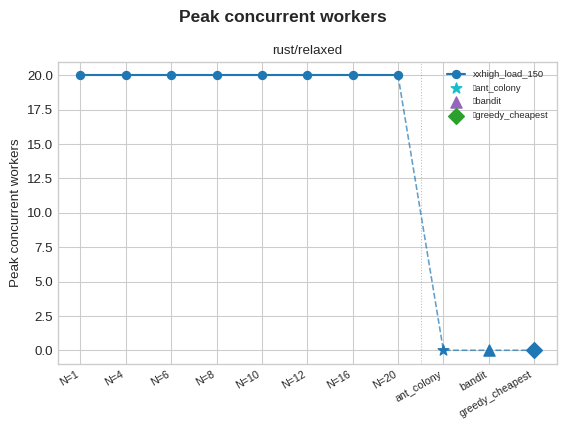

/tmp/ipykernel_58748/254711279.py:67: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


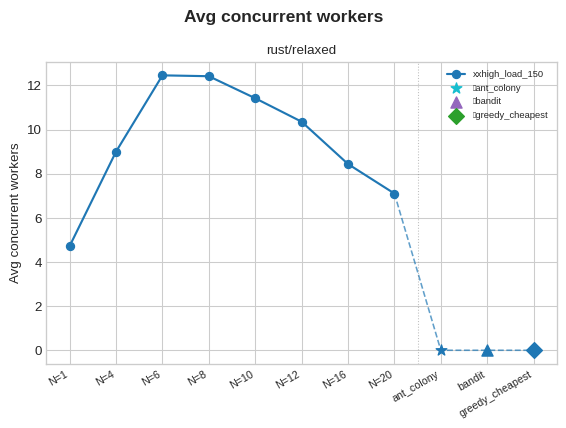

In [10]:
fig_w = max(6, 4.5 * max(len(combos), 1))
colors_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sid_color = {sid: colors_cycle[i % len(colors_cycle)] for i, sid in enumerate(scenarios)}

for m in METRICS:
    fig, axes = plt.subplots(1, max(len(combos), 1), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) <= 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel(m["label"])

        for sid in scenarios:
            sub = df_modes[
                (df_modes["scenario_id"] == sid) &
                (df_modes["backend"] == backend) &
                (df_modes["infeasibility_mode"] == mode)
            ].sort_values("batch_size")
            if sub.empty:
                continue
            xs = [bs_to_x[bs] for bs in sub["batch_size"]]
            ys = list(sub[m["col"]].values)
            ax.plot(xs, ys,
                    marker="o", linewidth=1.6, color=sid_color[sid], label=sid)
            # Dashed extension from last N-point through strategy points
            if not df_strat.empty and STRATEGY_NAMES:
                ext_xs = [xs[-1]]
                ext_ys = [ys[-1]]
                for strat in STRATEGY_NAMES:
                    sub_s = df_strat[
                        (df_strat["scenario_id"] == sid) &
                        (df_strat["infeasibility_mode"] == strat)
                    ]
                    if sub_s.empty or m["col"] not in sub_s.columns:
                        continue
                    ext_xs.append(strat_to_x[strat])
                    ext_ys.append(float(sub_s[m["col"]].values[0]))
                if len(ext_xs) > 1:
                    ax.plot(ext_xs, ext_ys, linestyle="--", linewidth=1.2,
                            alpha=0.7, color=sid_color[sid])

        # Strategy points per scenario (same color as scenario, distinct marker)
        for strat in STRATEGY_NAMES:
            for sid in scenarios:
                sub_s = df_strat[
                    (df_strat["scenario_id"] == sid) &
                    (df_strat["infeasibility_mode"] == strat)
                ]
                if sub_s.empty or m["col"] not in sub_s.columns:
                    continue
                sty = _strategy_style(strat)
                ax.scatter([strat_to_x[strat]], [sub_s[m["col"]].values[0]],
                           s=70, zorder=5, color=sid_color[sid], marker=sty["marker"])

        # Strategy legend markers (one entry per strategy, color=gray)
        for strat in STRATEGY_NAMES:
            sty = _strategy_style(strat)
            ax.scatter([], [], s=70, marker=sty["marker"],
                       color=sty["color"], label=f"▸{strat}")

        _apply_xaxis(ax)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


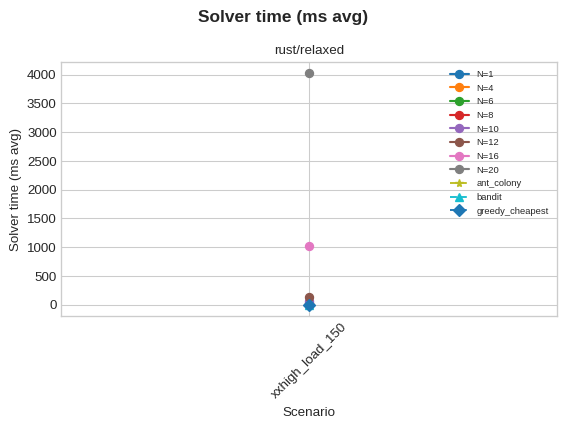

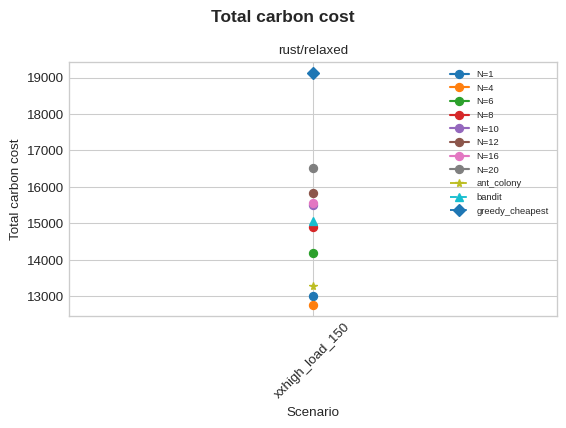

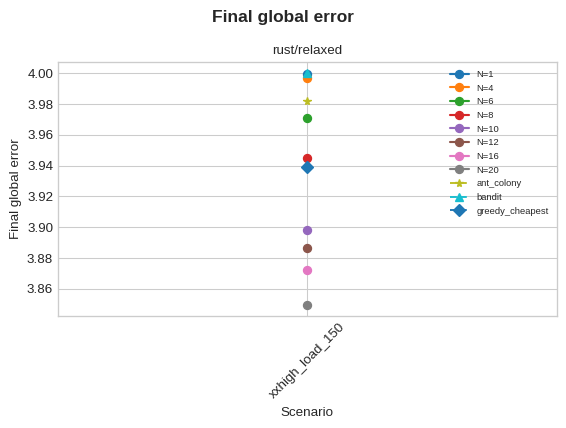

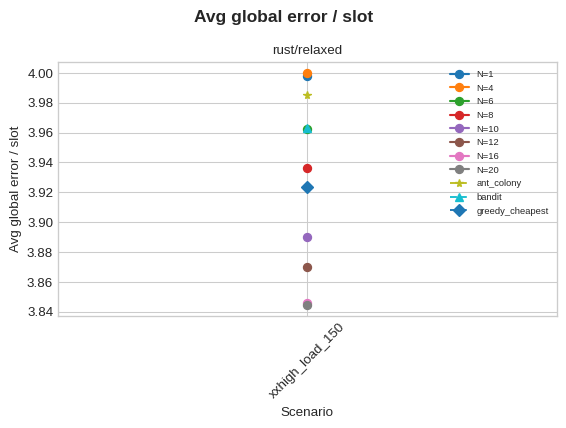

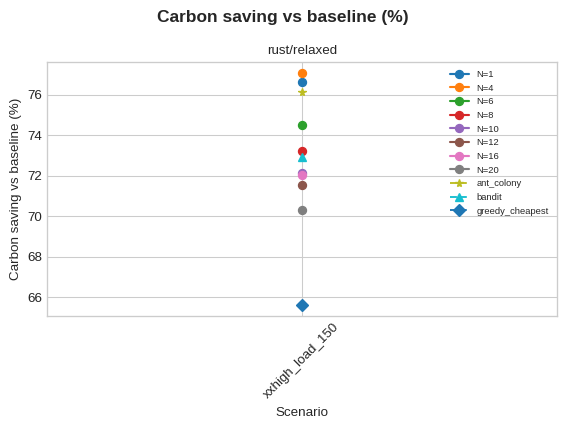

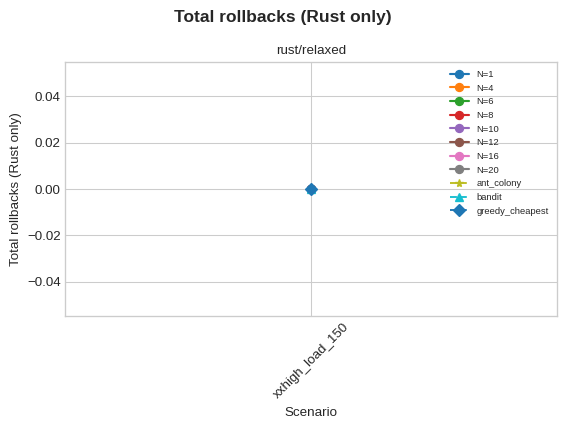

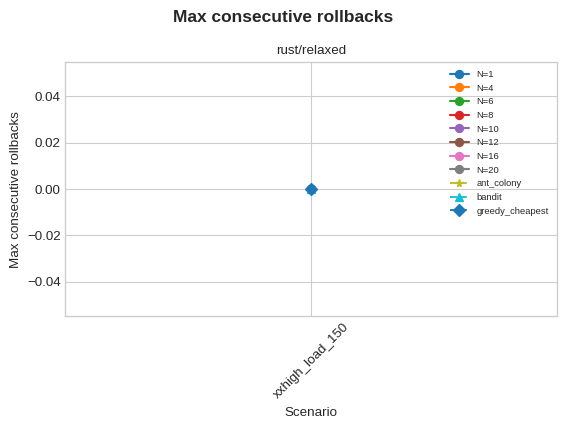

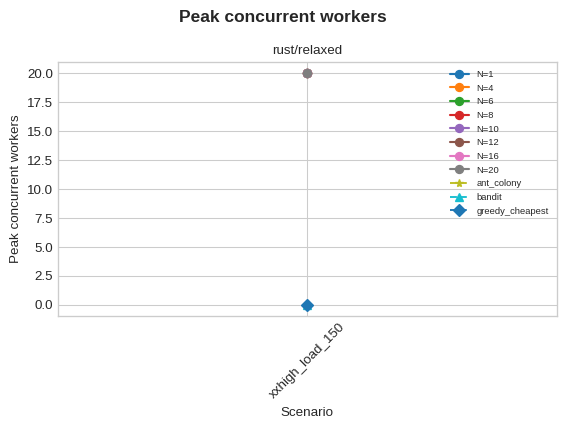

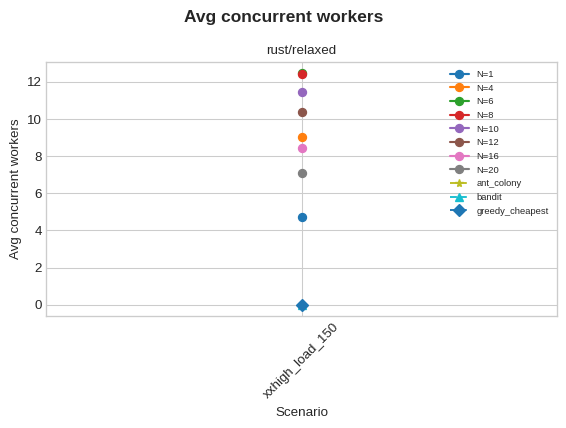

In [11]:
fig_w = max(6, 4.5 * max(len(combos), 1))
colors_cycle2 = plt.rcParams["axes.prop_cycle"].by_key()["color"]
bs_color = {bs: colors_cycle2[i % len(colors_cycle2)] for i, bs in enumerate(batch_sizes)}
strat_color = {
    s: colors_cycle2[(len(batch_sizes) + i) % len(colors_cycle2)]
    for i, s in enumerate(STRATEGY_NAMES)
}

for m in METRICS:
    fig, axes = plt.subplots(1, max(len(combos), 1), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) <= 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        ax.set_xlabel("Scenario")
        if ax is axes[0]:
            ax.set_ylabel(m["label"])

        for bs in batch_sizes:
            sub = (
                df_modes[
                    (df_modes["backend"] == backend) &
                    (df_modes["infeasibility_mode"] == mode) &
                    (df_modes["batch_size"] == bs)
                ]
                .set_index("scenario_id")
                .reindex(scenarios)
            )
            ax.plot(scenarios, sub[m["col"]].values,
                    marker="o", linewidth=1.6, color=bs_color[bs], label=f"N={bs}")

        # Strategies as additional lines (one point per scenario)
        for strat in STRATEGY_NAMES:
            if df_strat.empty:
                continue
            sub_s = (
                df_strat[df_strat["infeasibility_mode"] == strat]
                .set_index("scenario_id")
                .reindex(scenarios)
            )
            if m["col"] not in sub_s.columns:
                continue
            sty = _strategy_style(strat)
            ax.plot(scenarios, sub_s[m["col"]].values,
                    marker=sty["marker"], linewidth=1.4, linestyle="--",
                    color=strat_color[strat], label=strat)

        ax.legend(fontsize=7, loc="best")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## Aggregate statistics across all scenarios

Min / mean / max of each metric, grouped by `(backend, infeasibility_mode, batch_size)`.


In [12]:
metric_cols = [m["col"] for m in METRICS]
agg_modes = (
    df_modes.groupby(["backend", "infeasibility_mode", "batch_size"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("=== Modes: min / mean / max per (backend, mode, batch_size) ===")
display(agg_modes)

if not df_strat.empty:
    agg_strat = (
        df_strat.groupby(["infeasibility_mode"])[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\n=== Strategies: min / mean / max across all scenarios ===")
    display(agg_strat)


=== Modes: min / mean / max per (backend, mode, batch_size) ===


solver_time_ms_avg                      \
                                                     min      mean       max   
backend infeasibility_mode batch_size                                          
rust    relaxed_retry      1                      1.0147    1.0147    1.0147   
                           4                      4.0355    4.0355    4.0355   
                           6                     18.2829   18.2829   18.2829   
                           8                     38.0210   38.0210   38.0210   
                           10                    69.0181   69.0181   69.0181   
                           12                   128.3207  128.3207  128.3207   
                           16                  1017.8241 1017.8241 1017.8241   
                           20                  4025.7289 4025.7289 4025.7289   

                                      total_carbon_cost                        \
                                                    min       mean        max   
backend infeasibility_mode batch_size                                           
rust    relaxed_retry      1                 12998.7558 12998.7558 12998.7558   
                           4                 12768.9841 12768.9841 12768.9841   
                           6                 14190.8104 14190.8104 14190.8104   
                           8                 14895.7254 14895.7254 14895.7254   
                           10                15509.0227 15509.0227 15509.0227   
                           12                15841.6703 15841.6703 15841.6703   
                           16                15565.6163 15565.6163 15565.6163   
                           20                16530.1380 16530.1380 16530.1380   

                                      final_global_error                \
                                                     min   mean    max   
backend infeasibility_mode batch_size                                    
rust    relaxed_retry      1                      3.9995 3.9995 3.9995   
                           4                      3.9971 3.9971 3.9971   
                           6                      3.9711 3.9711 3.9711   
                           8                      3.9451 3.9451 3.9451   
                           10                     3.8984 3.8984 3.8984   
                           12                     3.8867 3.8867 3.8867   
                           16                     3.8720 3.8720 3.8720   
                           20                     3.8496 3.8496 3.8496   

                                      avg_global_error_per_slot                \
                                                            min   mean    max   
backend infeasibility_mode batch_size                                           
rust    relaxed_retry      1                             3.9977 3.9977 3.9977   
                           4                             3.9998 3.9998 3.9998   
                           6                             3.9627 3.9627 3.9627   
                           8                             3.9360 3.9360 3.9360   
                           10                            3.8903 3.8903 3.8903   
                           12                            3.8702 3.8702 3.8702   
                           16                            3.8459 3.8459 3.8459   
                           20                            3.8447 3.8447 3.8447   

                                      carbon_cost_saving_vs_baseline_pct  \
                                                                     min   
backend infeasibility_mode batch_size                                      
rust    relaxed_retry      1                                     76.6395   
                           4                                     77.0524   
                           6                                     74.4972   
                           8                                     73.2304   
                          


=== Strategies: min / mean / max across all scenarios ===


solver_time_ms_avg               total_carbon_cost  \
                                  min   mean    max               min   
infeasibility_mode                                                      
ant_colony                     0.0000 0.0000 0.0000        13287.5458   
bandit                         0.0000 0.0000 0.0000        15063.1742   
greedy_cheapest                0.0000 0.0000 0.0000        19120.9027   

                                         final_global_error                \
                         mean        max                min   mean    max   
infeasibility_mode                                                          
ant_colony         13287.5458 13287.5458             3.9817 3.9817 3.9817   
bandit             15063.1742 15063.1742             4.0000 4.0000 4.0000   
greedy_cheapest    19120.9027 19120.9027             3.9390 3.9390 3.9390   

                   avg_global_error_per_slot                \
                                         min   mean    max   
infeasibility_mode                                           
ant_colony                            3.9855 3.9855 3.9855   
bandit                                3.9632 3.9632 3.9632   
greedy_cheapest                       3.9237 3.9237 3.9237   

                   carbon_cost_saving_vs_baseline_pct                  \
                                                  min    mean     max   
infeasibility_mode                                                      
ant_colony                                    76.1205 76.1205 76.1205   
bandit                                        72.9294 72.9294 72.9294   
greedy_cheapest                               65.6372 65.6372 65.6372   

                   total_rollbacks            max_consecutive_rollbacks  \
                               min   mean max                       min   
infeasibility_mode                                                        
ant_colony                       0 0.0000   0                         0   
bandit                           0 0.0000   0                         0   
greedy_cheapest                  0 0.0000   0                         0   

                              peak_concurrent_workers             \
                     mean max                     min   mean max   
infeasibility_mode                                                 
ant_colony         0.0000   0                       0 0.0000   0   
bandit             0.0000   0                       0 0.0000   0   
greedy_cheapest    0.0000   0                       0 0.0000   0   

                   avg_concurrent_workers                
                                      min   mean    max  
infeasibility_mode                                       
ant_colony                         0.0000 0.0000 0.0000  
bandit                             0.0000 0.0000 0.0000  
greedy_cheapest                    0.0000 0.0000 0.0000

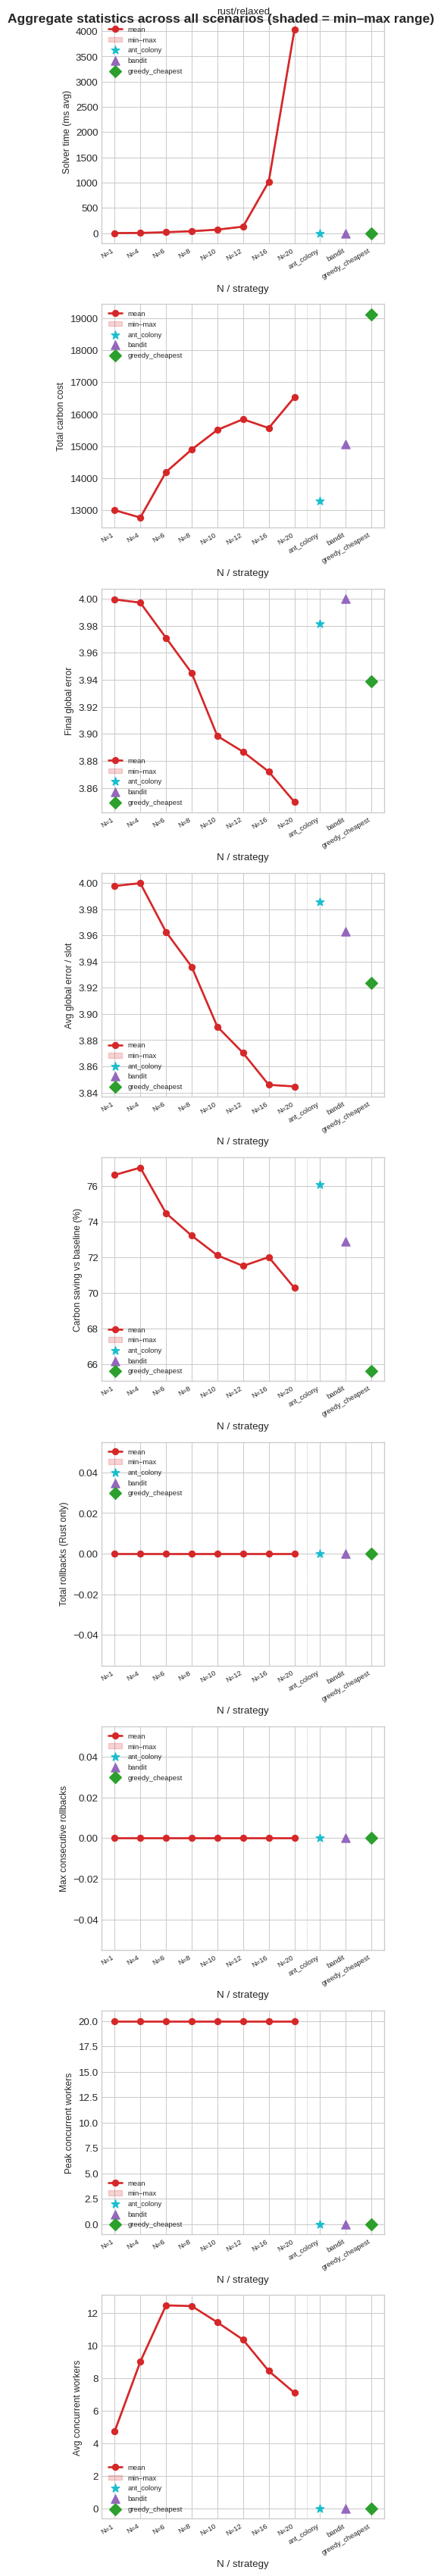

In [13]:
combos_sorted = sorted(combos)
fig_rows = len(METRICS)
fig_cols = max(len(combos_sorted), 1)

fig, axes = plt.subplots(
    fig_rows, fig_cols,
    figsize=(4.8 * fig_cols, 4.0 * fig_rows),
    squeeze=False,
    sharey="row",
)
fig.suptitle("Aggregate statistics across all scenarios (shaded = min–max range)\n",
             fontsize=13, fontweight="bold")

for row, m in enumerate(METRICS):
    for col, (backend, mode) in enumerate(combos_sorted):
        ax = axes[row][col]
        sub = df_modes[(df_modes["backend"] == backend) & (df_modes["infeasibility_mode"] == mode)]
        if sub.empty:
            ax.set_visible(False)
            continue
        grp = (
            sub.groupby("batch_size")[m["col"]]
            .agg(["min", "mean", "max"])
            .reset_index()
            .sort_values("batch_size")
        )
        xs = [bs_to_x[bs] for bs in grp["batch_size"]]
        color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
        ax.plot(xs, grp["mean"], marker="o", linewidth=2.0, color=color, label="mean")
        ax.fill_between(xs, grp["min"], grp["max"], alpha=0.2, color=color, label="min–max")
        ax.plot(xs, grp["min"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        ax.plot(xs, grp["max"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)

        # Strategy points: mean ± range across scenarios
        for strat in STRATEGY_NAMES:
            if df_strat.empty:
                continue
            vals = df_strat[df_strat["infeasibility_mode"] == strat][m["col"]].dropna()
            if vals.empty:
                continue
            x_pos = strat_to_x[strat]
            sty = _strategy_style(strat)
            sc = ax.scatter([x_pos], [vals.mean()], s=70, zorder=5,
                            color=sty["color"], marker=sty["marker"], label=strat)
            ax.plot([x_pos, x_pos], [vals.min(), vals.max()],
                    color=sty["color"], linewidth=2.5, alpha=0.6)

        if STRATEGY_NAMES and n_bs > 0:
            ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.8, alpha=0.5, color="gray")
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=7)
        ax.set_xlabel("N / strategy")
        if row == 0:
            ax.set_title(_series_label(backend, mode), fontsize=10)
        if col == 0:
            ax.set_ylabel(m["label"], fontsize=9)
        ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()


In [14]:
metric_cols = [m["col"] for m in METRICS]

overall_modes = (
    df_modes.groupby(["backend", "infeasibility_mode"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("Overall min / mean / max across ALL scenarios and ALL N values (modes):")
display(overall_modes)

if not df_strat.empty:
    overall_strat = (
        df_strat.groupby("infeasibility_mode")[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\nOverall min / mean / max across ALL scenarios (strategies):")
    display(overall_strat)


Overall min / mean / max across ALL scenarios and ALL N values (modes):


solver_time_ms_avg                     \
                                          min     mean       max   
backend infeasibility_mode                                         
rust    relaxed_retry                  1.0147 662.7807 4025.7289   

                           total_carbon_cost                        \
                                         min       mean        max   
backend infeasibility_mode                                           
rust    relaxed_retry             12768.9841 14787.5904 16530.1380   

                           final_global_error                \
                                          min   mean    max   
backend infeasibility_mode                                    
rust    relaxed_retry                  3.8496 3.9274 3.9995   

                           avg_global_error_per_slot                \
                                                 min   mean    max   
backend infeasibility_mode                                           
rust    relaxed_retry                         3.8447 3.9184 3.9998   

                           carbon_cost_saving_vs_baseline_pct                  \
                                                          min    mean     max   
backend infeasibility_mode                                                      
rust    relaxed_retry                                 70.2931 73.4247 77.0524   

                           total_rollbacks             \
                                       min   mean max   
backend infeasibility_mode                              
rust    relaxed_retry                    0 0.0000   0   

                           max_consecutive_rollbacks             \
                                                 min   mean max   
backend infeasibility_mode                                        
rust    relaxed_retry                              0 0.0000   0   

                           peak_concurrent_workers              \
                                               min    mean max   
backend infeasibility_mode                                       
rust    relaxed_retry                           20 20.0000  20   

                           avg_concurrent_workers                 
                                              min   mean     max  
backend infeasibility_mode                                        
rust    relaxed_retry                      4.7239 9.4892 12.4569


Overall min / mean / max across ALL scenarios (strategies):


solver_time_ms_avg               total_carbon_cost  \
                                  min   mean    max               min   
infeasibility_mode                                                      
ant_colony                     0.0000 0.0000 0.0000        13287.5458   
bandit                         0.0000 0.0000 0.0000        15063.1742   
greedy_cheapest                0.0000 0.0000 0.0000        19120.9027   

                                         final_global_error                \
                         mean        max                min   mean    max   
infeasibility_mode                                                          
ant_colony         13287.5458 13287.5458             3.9817 3.9817 3.9817   
bandit             15063.1742 15063.1742             4.0000 4.0000 4.0000   
greedy_cheapest    19120.9027 19120.9027             3.9390 3.9390 3.9390   

                   avg_global_error_per_slot                \
                                         min   mean    max   
infeasibility_mode                                           
ant_colony                            3.9855 3.9855 3.9855   
bandit                                3.9632 3.9632 3.9632   
greedy_cheapest                       3.9237 3.9237 3.9237   

                   carbon_cost_saving_vs_baseline_pct                  \
                                                  min    mean     max   
infeasibility_mode                                                      
ant_colony                                    76.1205 76.1205 76.1205   
bandit                                        72.9294 72.9294 72.9294   
greedy_cheapest                               65.6372 65.6372 65.6372   

                   total_rollbacks            max_consecutive_rollbacks  \
                               min   mean max                       min   
infeasibility_mode                                                        
ant_colony                       0 0.0000   0                         0   
bandit                           0 0.0000   0                         0   
greedy_cheapest                  0 0.0000   0                         0   

                              peak_concurrent_workers             \
                     mean max                     min   mean max   
infeasibility_mode                                                 
ant_colony         0.0000   0                       0 0.0000   0   
bandit             0.0000   0                       0 0.0000   0   
greedy_cheapest    0.0000   0                       0 0.0000   0   

                   avg_concurrent_workers                
                                      min   mean    max  
infeasibility_mode                                       
ant_colony                         0.0000 0.0000 0.0000  
bandit                             0.0000 0.0000 0.0000  
greedy_cheapest                    0.0000 0.0000 0.0000